## Import Packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Import 'Tensorflow' pakage
import tensorflow as tf
from tensorflow import keras

# Check the version of tensorflow
print(tf.__version__)

2.19.0


In [3]:
# Check if a GPU(in Google server) is allocated
device_name = tf.test.gpu_device_name()
if device_name != "/device:GPU:0":
    raise SystemError("GPU device not found")

print("Found GPU at: {}".format(device_name))

Found GPU at: /device:GPU:0


In [5]:
# Acess to google drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Load the SELECTED (Top 30) Feature Dataset
* Results of ML3-1 and ML3-2

In [6]:
FeatureSelected = pd.read_csv(
    "https://github.com/rd908213/ME-597-IIoT/blob/main/ml_tutorial/ML3/data/FeatureSelected.csv?raw=true",
    header=None,
)
FeatureSelected = FeatureSelected.T
FeatureSelected.shape

(360, 30)

In [7]:
# Standardize feature values
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected)
FeatureSelected_std.shape

(360, 30)

## Split Training & Test Data
- Use 'train_test_split' function
- It randomly samples the training and testing data according to the designated ratio.

In [8]:
# Number of data for each condition: 180
NoOfData = int(FeatureSelected_std.shape[0] / 2)

NormalSet = FeatureSelected_std[:NoOfData, :]
AbnormalSet = FeatureSelected_std[NoOfData:, :]

NormalSet.shape, AbnormalSet.shape

((180, 30), (180, 30))

In [9]:
from sklearn.model_selection import train_test_split

# Designate test data ratio
TestData_Ratio = 0.2

TrainData_Nor, TestData_Nor = train_test_split(
    NormalSet, test_size=TestData_Ratio, random_state=777
)
TrainData_Abn, TestData_Abn = train_test_split(
    AbnormalSet, test_size=TestData_Ratio, random_state=777
)

print(TrainData_Nor.shape, TestData_Nor.shape)
print(TrainData_Abn.shape, TestData_Abn.shape)

(144, 30) (36, 30)
(144, 30) (36, 30)


## Data Labling (One-hot Encoding)
- Use 'np.zeros' and 'np.ones'
- '[1,0]' refers to 'Normal' and '[1,0]' refers to 'Abnormal' in this tutorial

In [10]:
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0], 2))
TrainLabel_Abn = np.ones((TrainData_Abn.shape[0], 2))
TestLabel_Nor = np.zeros((TestData_Nor.shape[0], 2))
TestLabel_Abn = np.ones((TestData_Abn.shape[0], 2))

TrainLabel_Nor[:, 0] = 1  # [1,0]: Normal
TrainLabel_Abn[:, 0] = 0  # [0,1]: Abnormal
TestLabel_Nor[:, 0] = 1  # [1,0]: Normal
TestLabel_Abn[:, 0] = 0  # [0,1]: Abnormal

print(TrainLabel_Nor.shape, TestLabel_Nor.shape)
print(TrainLabel_Abn.shape, TestLabel_Abn.shape)

(144, 2) (36, 2)
(144, 2) (36, 2)


In [11]:
TestLabel_Nor

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

## Data and Label Preparation

In [12]:
TrainData = np.concatenate([TrainData_Nor, TrainData_Abn], axis=0)
TestData = np.concatenate([TestData_Nor, TestData_Abn], axis=0)
TrainLabel = np.concatenate([TrainLabel_Nor, TrainLabel_Abn], axis=0)
TestLabel = np.concatenate([TestLabel_Nor, TestLabel_Abn], axis=0)

print(TrainData.shape, TestData.shape)
print(TrainLabel.shape, TestLabel.shape)

(288, 30) (72, 30)
(288, 2) (72, 2)


## Setting hyperparameters for training ANN(Artificial Neural Network)

In [13]:
learningRate = 0.0001
noOfNeuron = 16
Epoch = 200

## Designing an ANN architecture (based on Keras)

- Types of Activation Functions: https://keras.io/api/layers/activations/

- Types of Optimization Algorithms: https://keras.io/api/optimizers/

- Types of Loss Functions (for Classification)  https://keras.io/api/losses/probabilistic_losses/

In [14]:
def ANN_model(input_data):
    keras.backend.clear_session()  # clearing the Keras backend session (initiating variables)

    model = keras.Sequential()
    model.add(
        keras.layers.InputLayer(input_shape=(input_data.shape[1],))
    )  # Input  Layer
    model.add(
        keras.layers.Dense(
            units=noOfNeuron, activation=keras.activations.relu, name="Hidden1"
        )
    )  # Hidden Layer 1
    model.add(
        keras.layers.Dense(
            units=noOfNeuron, activation=keras.activations.relu, name="Hidden2"
        )
    )  # Hidden Layer 2
    model.add(
        keras.layers.Dense(
            units=2, activation=keras.activations.softmax, name="Output"
        )
    )  # Output Layer

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learningRate
        ),  # Optimization algorithm
        loss=keras.losses.CategoricalCrossentropy(),  # Loss function (objective function of Optimization)
        metrics=["accuracy"],
    )  # Metrics to measure during the training process
    return model

In [15]:
# Check the model architecture and the number of parameters
AnnModel = ANN_model(TrainData)
AnnModel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden1 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802 (3.13 KB)

 Trainable params: 802 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Check the parameter shape for each layer
for i in range(len(AnnModel.get_weights())):
    print(AnnModel.get_weights()[i].shape)

(30, 16)
(16,)
(16, 16)
(16,)
(16, 2)
(2,)


## ANN Model Training

In [17]:
tf.random.set_seed(777)  # Not necessarily required

# Model traning and validation
TraingHistory = AnnModel.fit(TrainData, TrainLabel, epochs=Epoch, verbose=1)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6331 - loss: 0.6562
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6555 - loss: 0.6337  
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6891 - loss: 0.6127 
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7063 - loss: 0.5932 
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7194 - loss: 0.5748 
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7361 - loss: 0.5575 
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7571 - loss: 0.5410 
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7777 - loss: 0.5254 
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7946 - loss: 0.5105 
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8315 - loss: 0.4966 
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8641 - loss: 0.4835 
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8774 - los

In [18]:
# Evaluation result for test data (not trained)
Loss, Accuracy = AnnModel.evaluate(TestData, TestLabel, verbose=0)
Loss, Accuracy  # The closer the Loss is to 0 and the closer the accuracy is to 1 (100%), the better.

(0.006216123234480619, 1.0)

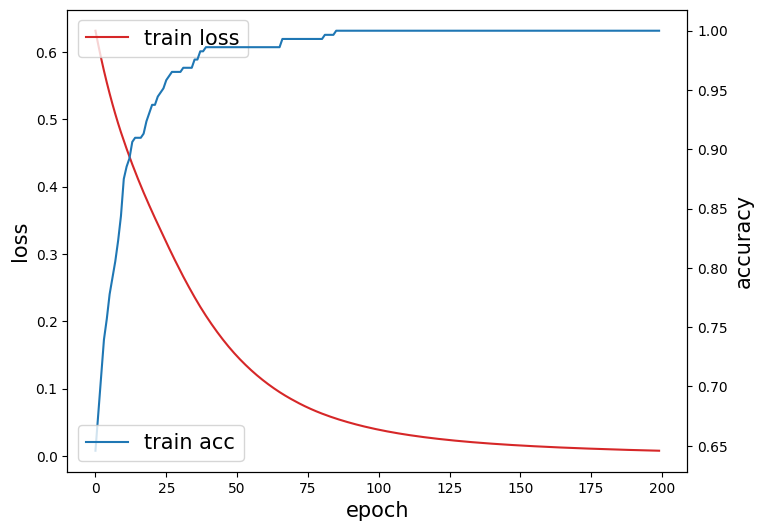

In [19]:
# Check the training process (Loss, Accuracy)

fig, loss_ax = plt.subplots(figsize=(8, 6))
acc_ax = loss_ax.twinx()

loss_ax.plot(TraingHistory.history["loss"], label="train loss", c="tab:red")
loss_ax.set_xlabel("epoch", fontsize=15)
loss_ax.set_ylabel("loss", fontsize=15)
loss_ax.legend(loc="upper left", fontsize=15)

acc_ax.plot(TraingHistory.history["accuracy"], label="train acc", c="tab:blue")
acc_ax.set_ylabel("accuracy", fontsize=15)
acc_ax.legend(loc="lower left", fontsize=15)

plt.show()

### [Tip] Defining a callback function to check the training progress at desired epochs

In [20]:
# Define the callback function
EpochForPrint = 20


class CheckProcess(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        keras.callbacks.Callback()
        if epoch % EpochForPrint == 0:
            print(
                "{} Epochs Train Acc. : {:.2f}%  ".format(
                    epoch, logs["accuracy"] * 100
                )
            )

In [21]:
AnnModel_2 = ANN_model(TrainData)
hist = AnnModel_2.fit(
    TrainData, TrainLabel, epochs=Epoch, verbose=0, callbacks=[CheckProcess()]
)

print(
    "Final Train Accuracy : {:.2f}%".format(hist.history["accuracy"][-1] * 100)
)

0 Epochs Train Acc. : 50.00%  
20 Epochs Train Acc. : 84.38%  
40 Epochs Train Acc. : 96.18%  
60 Epochs Train Acc. : 98.61%  
80 Epochs Train Acc. : 98.96%  
100 Epochs Train Acc. : 99.65%  
120 Epochs Train Acc. : 99.65%  
140 Epochs Train Acc. : 99.65%  
160 Epochs Train Acc. : 99.65%  
180 Epochs Train Acc. : 100.00%  
Final Train Accuracy : 100.00%


Save ML model (ANN) as a file

In [22]:
AnnModel.save(
    "/content/drive/MyDrive/Colab Notebooks/SavedFiles/ML_Models/ANN_model.h5"
)

Load the saved ML model (ANN) and test

In [23]:
LoadedModel = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/SavedFiles/ML_Models/ANN_model.h5"
)

Loss, Accuracy = LoadedModel.evaluate(TestData, TestLabel, verbose=0)
print("[Performance of ANN model] \n")
print("Accuracy : {:.2f}%".format(Accuracy * 100))

[Performance of ANN model] 

Accuracy : 100.00%


In [24]:
# Predicted result
Predicted = LoadedModel.predict(TestData)
pd.DataFrame(Predicted)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


,0,1
0,0.966492,0.033508
1,0.996223,0.003777
2,0.998618,0.001382
3,0.998983,0.001017
4,0.999697,0.000303
...,...,...
67,0.000997,0.999003
68,0.002552,0.997449
69,0.018013,0.981987
70,0.003031,0.996969
